In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg


Fedichev Model Parameters
Scaled parameter: g (factor = 1)
  Value: 0.800000
dt                 = 0.050000
tmax               = 130.0
n_individuals      = 10,000
Simulating 10000 individuals...
All agents died by t=120.10. Stopping simulation.


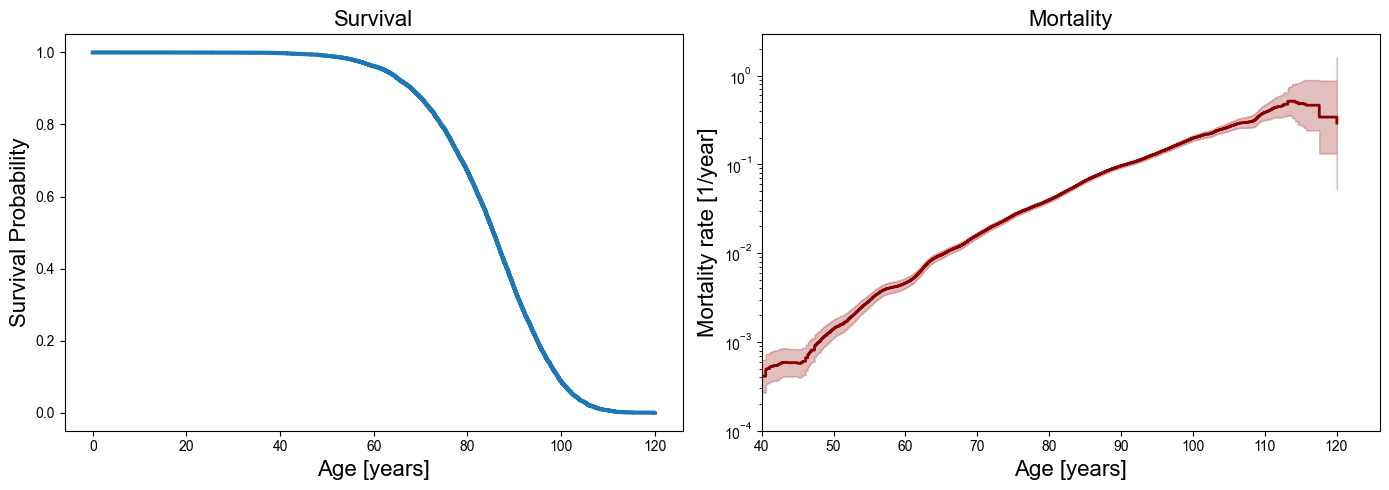

In [81]:
def simulate_fedichev_model(n_individuals=10000, dt=0.05, tmax=130, param_to_vary=None, std=0.05, param_factor=None):
    """
    Simulate the Fedichev aging model with optional parameter heterogeneity or scaling.
    
    Args:
        n_individuals (int): Number of individuals to simulate
        dt (float): Time step
        tmax (float): Maximum simulation time
        param_to_vary (str, optional): Parameter to vary across individuals. 
                                       One of: 'epsilon_0', 'D0', 'beta', 'g', 'gamma', 'beta_prime'
                                       If None, runs homogeneous simulation.
        std (float): Coefficient of variation (sigma = mean * std) for parameter distribution.
        param_factor (float, optional): If provided, multiplies param_to_vary by this factor instead of creating heterogeneity.
    
    Returns:
        np.ndarray: Death times for each individual
    """
    # --- Baseline Parameters ---
    epsilon_0_base = 4.0
    D0_base = 1.1  
    beta_base = 0.015
    g_base = 0.8
    gamma_base = 1.0
    beta_prime_base = 0.013333
    
    # Valid parameters that can be varied
    valid_params = ['epsilon_0', 'D0', 'beta', 'g', 'gamma', 'beta_prime']
    
    if param_to_vary is not None and param_to_vary not in valid_params:
        raise ValueError(f"param_to_vary must be one of {valid_params}, got '{param_to_vary}'")
    
    # --- Create parameter arrays (scalar or heterogeneous) ---
    def create_param_array(base_value, param_name):
        """Draw parameters from normal distribution, ensuring positivity, or scale by factor."""
        if param_to_vary == param_name:
            if param_factor is not None:
                # Scale the parameter by the factor (homogeneous)
                return base_value * param_factor
            else:
                # Create heterogeneous distribution
                sigma = base_value * std
                values = np.random.normal(base_value, sigma, n_individuals)
                # Resample negative values to ensure positivity
                while np.any(values <= 0):
                    neg_mask = values <= 0
                    values[neg_mask] = np.random.normal(base_value, sigma, np.sum(neg_mask))
                return values
        else:
            return base_value  # Return scalar for efficiency
    
    epsilon_0 = create_param_array(epsilon_0_base, 'epsilon_0')
    D0 = create_param_array(D0_base, 'D0')
    beta = create_param_array(beta_base, 'beta')
    g = create_param_array(g_base, 'g')
    gamma = create_param_array(gamma_base, 'gamma')
    beta_prime = create_param_array(beta_prime_base, 'beta_prime')
    
    # Print parameter info
    print("=" * 60)
    print("Fedichev Model Parameters")
    print("=" * 60)
    if param_to_vary:
        if param_factor is not None:
            print(f"Scaled parameter: {param_to_vary} (factor = {param_factor})")
            param_dict = {'epsilon_0': epsilon_0, 'D0': D0, 'beta': beta, 
                          'g': g, 'gamma': gamma, 'beta_prime': beta_prime}
            scaled_value = param_dict[param_to_vary]
            print(f"  Value: {scaled_value:.6f}")
        else:
            print(f"Varying parameter: {param_to_vary} (std = {std})")
            param_dict = {'epsilon_0': epsilon_0, 'D0': D0, 'beta': beta, 
                          'g': g, 'gamma': gamma, 'beta_prime': beta_prime}
            varied = param_dict[param_to_vary]
            print(f"  Mean: {np.mean(varied):.6f}, Std: {np.std(varied):.6f}, CV: {np.std(varied)/np.mean(varied):.3f}")
    else:
        print("Homogeneous parameters (no variation)")
        print(f"β' (beta_prime)    = {beta_prime_base:.6f}")
        print(f"ε₀ (epsilon_0)     = {epsilon_0_base:.6f}")
        print(f"γ (gamma)          = {gamma_base:.6f}")
        print(f"β (beta)           = {beta_base:.6f}")
        print(f"g                  = {g_base:.6f}")
        print(f"D₀ (D0)            = {D0_base:.6f}")
    print(f"dt                 = {dt:.6f}")
    print(f"tmax               = {tmax:.1f}")
    print(f"n_individuals      = {n_individuals:,}")
    print("=" * 60)
    
    # --- Euler-Maruyama Simulation ---
    sim_steps = int(tmax / dt)
    z = np.zeros(n_individuals)  # Everyone starts at z=0
    death_times = np.full(n_individuals, np.nan)
    alive_mask = np.ones(n_individuals, dtype=bool)
    
    sqrt_dt = np.sqrt(dt)
    noise_strength = np.sqrt(2 * D0)  # Scalar or vector depending on D0
    
    print(f"Simulating {n_individuals} individuals...")
    
    for i in range(sim_steps):
        t = i * dt
        
        # Check if all agents have died
        if np.sum(alive_mask) == 0:
            print(f"All agents died by t={t:.2f}. Stopping simulation.")
            break
        
        # Z = gamma * t (vector if gamma is heterogeneous, scalar otherwise)
        Z = gamma * t
        
        # Per-agent effective barrier and discriminant (vectorized)
        epsilon_eff = epsilon_0 - beta_prime * Z
        discriminant = epsilon_eff**2 - 4 * g * (beta * Z)
        
        # Get indices of alive agents
        alive_indices = np.where(alive_mask)[0]
        
        # Extract discriminant for alive agents
        if isinstance(discriminant, np.ndarray):
            disc_alive = discriminant[alive_indices]
        else:
            disc_alive = discriminant  # scalar case
        
        # Check stability: which agents still have a barrier
        if isinstance(disc_alive, np.ndarray):
            stable_mask = disc_alive > 0
            bifurcated_mask = ~stable_mask
        else:
            # Scalar case - either all stable or all bifurcated
            if disc_alive > 0:
                stable_mask = np.ones(len(alive_indices), dtype=bool)
                bifurcated_mask = np.zeros(len(alive_indices), dtype=bool)
            else:
                stable_mask = np.zeros(len(alive_indices), dtype=bool)
                bifurcated_mask = np.ones(len(alive_indices), dtype=bool)
        
        # --- Handle agents past bifurcation (barrier vanished, instant death) ---
        if np.any(bifurcated_mask):
            bifurc_indices = alive_indices[bifurcated_mask]
            death_times[bifurc_indices] = t
            alive_mask[bifurc_indices] = False
        
        # --- Handle agents with stable barrier ---
        if np.any(stable_mask):
            stable_indices = alive_indices[stable_mask]
            
            # Helper to extract values for stable agents
            def get_stable(arr, mask):
                if isinstance(arr, np.ndarray):
                    return arr[alive_indices][mask]
                return arr  # scalar
            
            eps_stable = get_stable(epsilon_eff, stable_mask)
            disc_stable = get_stable(discriminant, stable_mask)
            g_stable = get_stable(g, stable_mask)
            beta_stable = get_stable(beta, stable_mask)
            Z_stable = get_stable(Z, stable_mask) if isinstance(Z, np.ndarray) else Z
            noise_stable = get_stable(noise_strength, stable_mask)
            
            # Calculate critical point z_unstable for each stable agent
            z_unstable = (eps_stable + np.sqrt(disc_stable)) / (2 * g_stable)
            
            # Current z values for stable agents
            z_curr = z[stable_indices]
            
            # Langevin dynamics: drift + diffusion
            drift = (beta_stable * Z_stable) - (eps_stable * z_curr) + (g_stable * z_curr**2)
            diffusion = noise_stable * np.random.normal(0, sqrt_dt, size=len(stable_indices))
            
            # Update z
            z_new = z_curr + drift * dt + diffusion
            z[stable_indices] = z_new
            
            # Check threshold crossing: each agent vs their OWN z_unstable
            died_now = z_new > z_unstable
            
            if np.any(died_now):
                died_indices = stable_indices[died_now]
                death_times[died_indices] = t
                alive_mask[died_indices] = False
    
    return death_times


def plot_survival_and_hazard(death_times, ax1, ax2, labelfontsize):
    valid = death_times[~np.isnan(death_times)]
    
    # --- 1. Survival Curve using Kaplan-Meier ---
    kmf_fitter = KaplanMeierFitter()
    kmf_fitter.fit(valid)
    
    # --- 2. Hazard Rate using Nelson-Aalen ---
    naf_fitter = NelsonAalenFitter()
    naf_fitter.fit(valid)
    
    # Survival
    kmf_fitter.plot_survival_function(ax=ax1, lw=3, legend=False)
    ax1.set_xlabel("Age [years]", fontfamily='Arial', fontsize=labelfontsize)
    ax1.set_ylabel("Survival Probability", fontfamily='Arial', fontsize=labelfontsize)
    ax1.set_title("Survival", fontfamily='Arial', fontsize=labelfontsize)
    for label in ax1.get_xticklabels() + ax1.get_yticklabels():
        label.set_fontfamily('Arial')
    
    # Hazard (smoothed)
    naf_fitter.plot_hazard(ax=ax2, bandwidth=3, color='darkred', lw=2, legend=False)
    ax2.set_xlabel("Age [years]", fontfamily='Arial', fontsize=labelfontsize)
    ax2.set_ylabel("Mortality rate [1/year]", fontfamily='Arial', fontsize=labelfontsize)
    ax2.set_title("Mortality", fontfamily='Arial', fontsize=labelfontsize)
    ax2.set_yscale('log')
    ax2.set_xlim(left=40)
    ax2.set_ylim(bottom=0.0001)
    for label in ax2.get_xticklabels() + ax2.get_yticklabels():
        label.set_fontfamily('Arial')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
deaths = simulate_fedichev_model(n_individuals=10000, param_to_vary='g', param_factor=1)
plot_survival_and_hazard(deaths, ax1, ax2, labelfontsize=16)
plt.tight_layout()
plt.savefig('Figures/fedichev_survival_mortality.pdf', bbox_inches='tight')
plt.show()


## creating hetero results for fedichev model

In [62]:
# Double loop over parameters and std values
import pickle
import os

params_to_vary = ['beta_prime', 'beta','gamma', 'g', 'D0', 'epsilon_0']
std_values = np.arange(0, 0.201, 0.025)

fedichev_hetero_results = {}

for param in params_to_vary:
    fedichev_hetero_results[param] = {}
    for std in std_values:
        print(f"Running simulation for {param} with std={std:.3f}")
        death_times = simulate_fedichev_model(tmax=1000, param_to_vary=param, std=std, n_individuals=int(1e5))
        
        # Get top 100 death times (longest lived individuals)
        valid_deaths = death_times[~np.isnan(death_times)]
        top_100 = np.sort(valid_deaths)[-100:] if len(valid_deaths) >= 100 else valid_deaths
        
        fedichev_hetero_results[param][f'std_{std:.3f}'] = top_100

# Save results to pickle file
os.makedirs('saved_results', exist_ok=True)
with open('saved_results/fedichev_hetero_results.pkl', 'wb') as f:
    pickle.dump(fedichev_hetero_results, f)

print("Results saved to saved_results/fedichev_hetero_results.pkl")

Running simulation for beta_prime with std=0.000
Fedichev Model Parameters
Varying parameter: beta_prime (std = 0.0)
  Mean: 0.013333, Std: 0.000000, CV: 0.000
dt                 = 0.050000
tmax               = 1000.0
n_individuals      = 100,000
Simulating 100000 individuals...
All agents died by t=120.10. Stopping simulation.
Running simulation for beta_prime with std=0.025
Fedichev Model Parameters
Varying parameter: beta_prime (std = 0.025)
  Mean: 0.013333, Std: 0.000333, CV: 0.025
dt                 = 0.050000
tmax               = 1000.0
n_individuals      = 100,000
Simulating 100000 individuals...
All agents died by t=122.65. Stopping simulation.
Running simulation for beta_prime with std=0.050
Fedichev Model Parameters
Varying parameter: beta_prime (std = 0.05)
  Mean: 0.013334, Std: 0.000665, CV: 0.050
dt                 = 0.050000
tmax               = 1000.0
n_individuals      = 100,000
Simulating 100000 individuals...
All agents died by t=127.55. Stopping simulation.
Running

# steepness longevity fedichev

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# --- 1. Simulation Logic (Same as before) ---

def run_simulation_beta_prime(n_individuals, dt, beta_prime, epsilon_0_init, gamma, beta, g, D0):
    sim_max_time = 200.0 
    time_steps = int(sim_max_time / dt)
    times = np.linspace(0, sim_max_time, time_steps)
    
    z = np.zeros(n_individuals)
    death_times = np.full(n_individuals, np.nan)
    alive_mask = np.ones(n_individuals, dtype=bool)
    
    sqrt_dt = np.sqrt(dt)
    sqrt_2D0 = np.sqrt(2 * D0)
    
    for t in times:
        n_alive = np.sum(alive_mask)
        if n_alive == 0:
            break
            
        Z = gamma * t
        epsilon_eff = epsilon_0_init - beta_prime * Z
        discriminant = epsilon_eff**2 - 4 * g * (beta * Z)
        
        if discriminant > 0:
            sqrt_disc = np.sqrt(discriminant)
            z_unstable = (epsilon_eff + sqrt_disc) / (2 * g)
            
            z_alive = z[alive_mask]
            drift = (beta * Z) - (epsilon_eff * z_alive) + (g * z_alive**2)
            diffusion = sqrt_2D0 * np.random.normal(0, sqrt_dt, size=n_alive)
            
            z_alive_new = z_alive + drift * dt + diffusion
            z[alive_mask] = z_alive_new
            
            died_now_local = z_alive_new > z_unstable
            if np.any(died_now_local):
                alive_indices = np.where(alive_mask)[0]
                dying_indices = alive_indices[died_now_local]
                death_times[dying_indices] = t
                alive_mask[dying_indices] = False
        else:
            alive_indices = np.where(alive_mask)[0]
            death_times[alive_indices] = t
            alive_mask[alive_indices] = False
            
    return death_times

def calculate_metrics(death_times):
    valid_deaths = death_times[~np.isnan(death_times)]
    if len(valid_deaths) < 10:
        return np.nan, np.nan
    median = np.median(valid_deaths)
    q75, q25 = np.percentile(valid_deaths, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return median, np.nan
    steepness = median / iqr
    return median, steepness

# --- 2. Run Simulations and Save Results ---

def run_and_save_fedichev_steepness_longevity():
    # Parameters - using baseline from file_context_0
    epsilon_0 = 4.0
    D0 = 1.1  
    beta = 0.015
    g = 0.8
    gamma = 1.0
    t_max = 120.0
    
    # Derive beta_prime to force the cliff at 120 years
    term_root = 4 * g * beta * gamma * t_max
    beta_prime = (epsilon_0 - np.sqrt(term_root)) / (gamma * t_max)
    
    base_params = {
        'beta_prime': beta_prime,
        'epsilon_0_init': epsilon_0,
        'gamma': gamma,
        'beta': beta,
        'g': g,
        'D0': D0
    }
    
    # Order of parameters
    param_order = ['beta_prime', 'epsilon_0_init', 'gamma', 'beta', 'g', 'D0']
    
    n_individuals = 100000
    dt = 0.05
    
    print("Running Baseline...")
    base_deaths = run_simulation_beta_prime(n_individuals, dt, **base_params)
    base_med, base_steep = calculate_metrics(base_deaths)
    
    # Sweep
    multipliers = np.arange(0.6, 1.40001, 0.1)
    results = {}
    
    for param in param_order:
        print(f"Sweeping {param}...")
        results[param] = {'x': [], 'y': []}
        
        for mult in multipliers:
            curr_params = base_params.copy()
            curr_params[param] = base_params[param] * mult
            deaths = run_simulation_beta_prime(n_individuals, dt, **curr_params)
            med, steep = calculate_metrics(deaths)
            
            if not np.isnan(med) and not np.isnan(steep):
                results[param]['x'].append(med / base_med)
                results[param]['y'].append(steep / base_steep)
    
    # Save results
    os.makedirs('saved_results', exist_ok=True)
    save_data = {
        'results': results,
        'param_order': param_order,
        'base_med': base_med,
        'base_steep': base_steep,
        'base_params': base_params
    }
    
    with open('saved_results/fedichev_model_steepness_longevity_data.pkl', 'wb') as f:
        pickle.dump(save_data, f)
    
    print("Results saved to saved_results/fedichev_model_steepness_longevity_data.pkl")


# --- 3. Plotting Function ---

from plotly.graph_objs import Font
# Color and label mappings for Fedichev model parameters
fedichev_colors = {
    'beta_prime': 'blue',
    'epsilon_0_init': 'green',
    'gamma': 'red',
    'beta': 'black',
    'g': 'purple',
    'D0': 'orange'
}
fedichev_labels = {
    'beta_prime': r"$\beta'$ (Resilience decay" + "\n" + "rate)",
    'epsilon_0_init': r'$\epsilon_0$ (Initial resilience)',
    'gamma': r'$\gamma$ (Damage accumulation' + "\n" + 'rate)',
    'beta': r'$\beta$ (Damage coupling)',
    'g': r'$g$ (Non-linearity)',
    'D0': r'$D_0$ (Noise)'
}


def plot_steepness_longevity_fedichev(
    ax=None, save_fig=False, filename=None, 
    alpha=1.0, marker_size_range=(40, 120), linewidth=4, transparent=True,
    legend_fontsize=20, label_fontsize=22, title_fontsize=22, styles=None
):
    # Load data
    with open('saved_results/fedichev_model_steepness_longevity_data.pkl', 'rb') as f:
        data = pickle.load(f)
    
    results = data['results']
    param_order = data['param_order']
    
    # Use provided styles or default to fedichev_colors and fedichev_labels
    if styles is None:
        colors = fedichev_colors
        labels = fedichev_labels
    else:
        # Extract colors and labels from styles dictionary
        colors = {param: style.get('color', 'black') for param, style in styles.items()}
        labels = {param: style.get('label', param) for param, style in styles.items()}
    
    # Marker size range
    min_size, max_size = marker_size_range
    
    # Get multipliers for marker sizing
    multipliers = np.arange(0.6, 1.40001, 0.1)
    min_mult, max_mult = min(multipliers), max(multipliers)
    
    # Create figure if ax not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9))
    
    for param in param_order:
        data_param = results[param]
        x = data_param['x']
        y = data_param['y']
        c = colors.get(param, 'black')
        
        # Get alpha from styles if provided, otherwise use default logic
        if styles and param in styles:
            alpha_val = styles[param].get('alpha', alpha)
        else:
            alpha_val = alpha if param == 'D0' else alpha * 0.5
        
        if len(x) > 0:
            # Plot line
            ax.plot(x, y, linestyle='-', linewidth=linewidth, color=c, label=labels.get(param, param), alpha=alpha_val)
            
            # Plot points with varying marker sizes
            for j, (xi, yi) in enumerate(zip(x, y)):
                mult = multipliers[j]
                # Normalize multiplier to [0, 1] range
                size_norm = (mult - min_mult) / (max_mult - min_mult)
                marker_size_val = min_size + (max_size - min_size) * size_norm
                
                ax.scatter(xi, yi, s=marker_size_val, color=c, edgecolors=c, linewidth=1, zorder=3, alpha=alpha_val)
            

    ax.axvline(1.0, color='gray', linestyle=':', alpha=0.6)
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6)
    
    ax.set_title("Only changes in noise amplitude and initial barrier height\nreproduce observed steepness-longevity curves", fontsize=title_fontsize, fontfamily='Arial')
    ax.set_xlabel("Median lifespan relative to baseline", fontsize=label_fontsize, fontfamily='Arial')
    ax.set_ylabel("Steepness relative to baseline", fontsize=label_fontsize, fontfamily='Arial')
    ax.tick_params(axis='both', which='major', labelsize=label_fontsize)
    for label in ax.get_xticklabels():
        label.set_fontfamily('Arial')
    for label in ax.get_yticklabels():
        label.set_fontfamily('Arial')
    ax.grid(False)
    
    # Create legend with title
    legend = ax.legend(loc='upper left', prop={'family': 'Arial', 'size': legend_fontsize}, 
                      title='Parameter changes', title_fontsize=legend_fontsize)
    legend.get_title().set_fontfamily('Arial')
    
    # Ensure legend text uses Arial and respects newlines
    for text in legend.get_texts():
        text.set_fontfamily('Arial')
    
    # Save figure if requested
    if save_fig and filename:
        os.makedirs('Figures', exist_ok=True)
        save_path = os.path.join('Figures', filename)
        plt.tight_layout()
        plt.savefig(save_path, format='pdf', bbox_inches='tight', transparent=transparent)
        print(f"Figure saved to {save_path}")
    
    # Only call tight_layout and show if we created the figure
    if ax is None:
        plt.tight_layout()
        plt.show()
    
    return ax



In [48]:
# Run simulations and save
run_and_save_fedichev_steepness_longevity()

Running Baseline...
Sweeping beta_prime...
Sweeping epsilon_0_init...
Sweeping gamma...
Sweeping beta...
Sweeping g...
Sweeping D0...
Results saved to saved_results/fedichev_model_steepness_longevity_data.pkl


# gompertz model stuff

## steepness longevity

In [65]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def summarize_death_times(death_times, from_t, min_samples=500):
    arr = np.asarray(death_times, dtype=float)
    arr = arr[(np.isfinite(arr)) & (arr >= from_t)]
    if arr.size < min_samples:
        return None
    rel = arr - from_t
    q25, q50, q75 = np.percentile(rel, [25, 50, 75])
    iqr = q75 - q25
    if iqr <= 0:
        return None
    return {
        "t_median_absolute": q50 + from_t,
        "t_median_relative": q50,
        "steepness_iqr_absolute": (q50 + from_t) / iqr,
        "steepness_iqr_relative": q50 / iqr,
        "iqr": iqr,
        "n_at_risk": arr.size,
    }

def build_factor_specs():
    return [
        {"key": "intercept_a_linear", "label": "Intercept a (× factor)", "color": "#90EE90", "linestyle": "-",
         "apply_fn": lambda base, f: {**base, "a": base["a"] * f}},
        {"key": "intercept_a_exp", "label": "Intercept a (^ factor)", "color": "#2ca02c", "linestyle": "-",
         "apply_fn": lambda base, f: {**base, "a": base["a"]**f}},
        {"key": "slope_b", "label": "Slope b", "color": "#1f77b4", "linestyle": "-",
         "apply_fn": lambda base, f: {**base, "b": base["b"] * f}},
        {"key": "coupled_intercept_slope", "label": "Coupled intercept + slope\n(SM correlation)", "color": "#9467bd", "linestyle": "-",
         "apply_fn": lambda base, f: {**base, "b": base["b"] * f, "a": base["a"] ** f}},
        {"key": "makeham_m", "label": "Makeham m", "color": "#d62728", "linestyle": "-",
         "apply_fn": lambda base, f: {**base, "m": f}},
    ]

def run_and_save_gompertz_steepness_longevity(model, factors=np.linspace(0.6, 1.4, 9), m_values=np.concatenate(([0], np.logspace(-4, -2, 20))),
                           from_t_values=(0,), n_samples=200_000, min_samples_after_filter=500, save_path=None):
    specs = build_factor_specs()
    base_params = {"a": model.a, "b": model.b, "c": model.c, "m": model.m}
    
    results = {"meta": {"factors": list(factors), "m_values": list(m_values), "from_t_values": list(from_t_values),
                        "n_samples": n_samples, "min_samples_after_filter": min_samples_after_filter}, "baseline": {}}
    
    baseline_deaths = model.sample_death_times(n=n_samples)
    for ft in from_t_values:
        results["baseline"][ft] = summarize_death_times(baseline_deaths, ft, min_samples_after_filter)
    
    summary_rows = []
    for spec in specs:
        param_results = {}
        sweep_values = m_values if spec["key"] == "makeham_m" else factors
        
        for val in sweep_values:
            params_override = spec["apply_fn"](base_params, val)
            deaths = model.sample_death_times(n=n_samples, params=params_override)
            per_ft = {ft: summarize_death_times(deaths, ft, min_samples_after_filter) for ft in from_t_values}
            param_results[val] = per_ft
            
            for ft in from_t_values:
                stats = per_ft.get(ft)
                if stats:
                    summary_rows.append({"parameter": spec["key"], "label": spec["label"], "color": spec["color"],
                                       "linestyle": spec["linestyle"], "factor": val, "from_t": ft,
                                       "t_median_abs": stats["t_median_absolute"], "t_median_rel": stats["t_median_relative"],
                                       "steepness_abs": stats["steepness_iqr_absolute"], "steepness_rel": stats["steepness_iqr_relative"]})
        
        results[spec["key"]] = param_results
    
    summary_df = pd.DataFrame(summary_rows)
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        with open(save_path, "wb") as f:
            pickle.dump({"results": results, "summary": summary_df}, f)
    
    return results, summary_df

def plot_steepness_longevity_gompertz(
    results_dict, summary_df, from_t=0, normalized=True, ax=None,
    alpha=1.0, marker_size_range=(40, 120), linewidth=4, transparent=True,
    legend_fontsize=20, label_fontsize=22, title_fontsize=22, styles=None
):
    # Fonts and sizes settings to make "identical" to fedichev panel B plot
    baseline = results_dict["baseline"][from_t]
    if baseline is None:
        raise ValueError(f"Baseline metrics missing for from_t={from_t}")

    df = summary_df[summary_df["from_t"] == from_t].copy()
    if df.empty:
        raise ValueError(f"No factor sweep rows for from_t={from_t}")

    if normalized:
        df["xval"] = df["t_median_abs"] / baseline["t_median_absolute"]
        df["yval"] = df["steepness_abs"] / baseline["steepness_iqr_absolute"]
        xlabel, ylabel = "Median lifespan relative to baseline", "Steepness relative to baseline"
        ref_line = 1.0
    else:
        df["xval"], df["yval"] = df["t_median_abs"], df["steepness_abs"]
        xlabel, ylabel = f"Median Lifespan (from t={from_t})", "Steepness (Median / IQR)"
        ref_line = None

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9))

    # Use provided styles dictionary or build default specs
    if styles is None:
        specs = build_factor_specs()
    else:
        # Convert styles dictionary to specs format
        specs = []
        for key, style_dict in styles.items():
            specs.append({
                "key": key,
                "label": style_dict.get("label", key),
                "color": style_dict.get("color", "black"),
                "linestyle": style_dict.get("linestyle", "-"),
            })

    legend_handles = []
    # Exact same legend structure as panel B/fedichev:
    for spec in specs:
        sub = df[df["parameter"] == spec["key"]].sort_values("factor")
        if sub.empty:
            continue
        
        # Get alpha from styles if provided, otherwise use default logic
        if styles and spec["key"] in styles:
            current_alpha = styles[spec["key"]].get("alpha", 1.0)
        else:
            current_alpha = 1.0 if spec["key"] == "coupled_intercept_slope" else 0.3
        
        current_linewidth = linewidth * 1.5 if current_alpha == 1.0 else linewidth
        size_norm = plt.Normalize(sub["factor"].min(), sub["factor"].max())
        sizes = marker_size_range[0] + (marker_size_range[1] - marker_size_range[0]) * size_norm(sub["factor"].values)
        # Plot line
        ax.plot(
            sub["xval"], sub["yval"], color=spec["color"], linewidth=current_linewidth,
            linestyle=spec["linestyle"], alpha=current_alpha, label=spec["label"]
        )
        # Scatter points
        ax.scatter(
            sub["xval"], sub["yval"], s=sizes, color=spec["color"], edgecolors=spec["color"],
            linewidth=1, zorder=3, alpha=current_alpha
        )
        # Add to legend
        legend_handles.append(
            plt.Line2D([0],[0], color=spec["color"], linestyle=spec["linestyle"],
                       linewidth=current_linewidth, label=spec["label"])
        )

    if ref_line is not None:
        ax.axhline(ref_line, color="gray", linestyle=":", alpha=0.6)
        ax.axvline(ref_line, color="gray", linestyle=":", alpha=0.6)

    ax.set_title("Only changes in noise amplitude and initial barrier height\nreproduce observed steepness-longevity curves",
                 fontsize=title_fontsize, fontfamily='Arial')
    ax.set_xlabel(xlabel, fontsize=label_fontsize, fontfamily='Arial')
    ax.set_ylabel(ylabel, fontsize=label_fontsize, fontfamily='Arial')

    ax.tick_params(axis='both', which='major', labelsize=label_fontsize-2, width=1.5, length=8)
    for label in ax.get_xticklabels():
        label.set_fontfamily('Arial')
    for label in ax.get_yticklabels():
        label.set_fontfamily('Arial')
    ax.grid(False)

    legend = ax.legend(
        handles=legend_handles,
        title="Parameter changes",
        loc='upper left',
        prop={'family': 'Arial', 'size': legend_fontsize},
        title_fontsize=legend_fontsize + 2
    )
    if legend:
        legend.get_title().set_fontfamily("Arial")
        legend.get_title().set_fontweight("bold")
        for text in legend.get_texts():
            text.set_fontfamily("Arial")
    return ax

In [10]:
model = gg()

HMD_params = {
    'country': 'dan',
    'year': 1880,
    'gender': 'male', 
    'data_type': 'cohort',
    'haz_type': 'mx'
}
model.fit_params(**HMD_params, filter_from=20, filter_to=105, print_out=False)

model.c = 100



In [96]:
model.print_params()

a:  1.9930012524070147e-05
b:  0.10768735406452468
c:  100
m:  0


## gompertz hetero

In [11]:
stds = [0, 0.025 , 0.05, 0.075, 0.1, 0.125 ,0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]

# get rid of c
model.c = 100

# Dictionary to store max lifespan vs std for each parameter
max_lifespan_results = {
    'a': [],
    'b': [],
    'b_coupled': [],  # for coupled a,b sampling
    'a_power_law': []  # for power-law scaling of a
}

for std in stds:
    for param in ['a', 'b']:
        death_times = model.sample_death_times_with_random_param(n=int(1e5), param_name=param, std=std)
        top_100 = np.sort(death_times[0])[-100:]
        max_lifespan_results[param].append(top_100)
    print(f'std = {std}')
    
    # Also do coupled a,b sampling
    death_times_coupled = model.sample_death_times_with_random_param(n=int(1e5), param_name='b', std=std, coupled_ab=True)
    top_100_coupled = np.sort(death_times_coupled[0])[-100:]
    max_lifespan_results['b_coupled'].append(top_100_coupled)
    
    # Also do power-law scaling for parameter a
    death_times_power_law = model.sample_death_times_with_random_param(n=int(1e5), param_name='a', std=std, power_law_scaling=True)
    top_100_power_law = np.sort(death_times_power_law[0])[-100:]
    max_lifespan_results['a_power_law'].append(top_100_power_law)

std = 0
std = 0.025
std = 0.05
std = 0.075
std = 0.1
std = 0.125
std = 0.15
std = 0.175
std = 0.2
std = 0.225
std = 0.25
std = 0.275
std = 0.3


# plotting Gompertz and Fedichev side by side

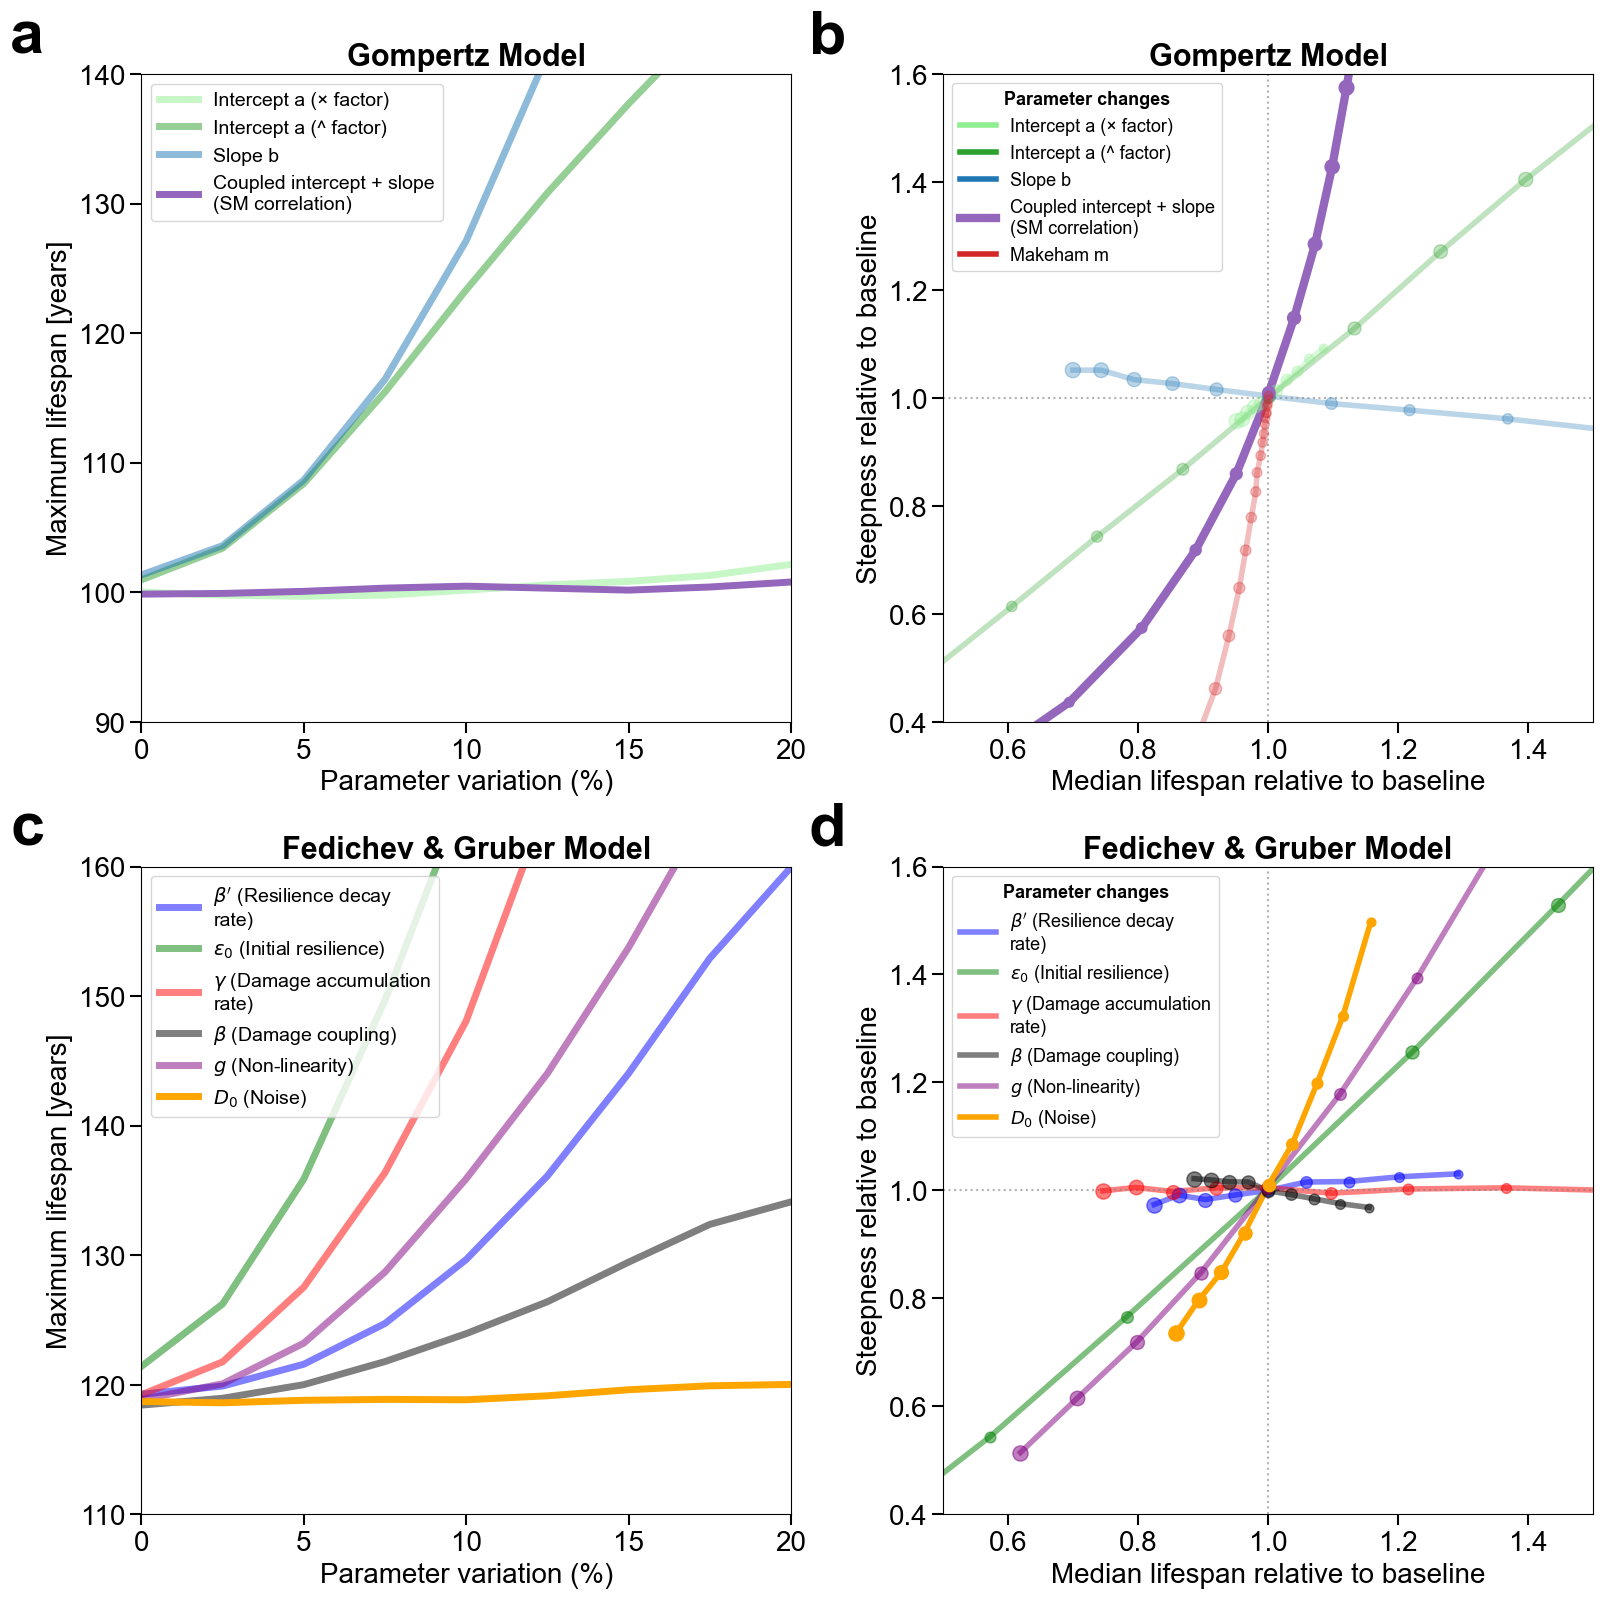

In [97]:
# Helper function to plot max lifespan panel
def plot_max_lifespan(ax, results, stds, styles, title, ylabel='Maximum lifespan [years]'):
    for param, style in styles.items():
        tenth_oldest = [np.sort(top_100)[-10] for top_100 in results[param]]
        smoothed = gaussian_filter1d(tenth_oldest, sigma=1.0)
        ax.plot(np.array(stds)*100, smoothed, linewidth=5, **style)
    ax.set_xlabel('Parameter variation (%)', fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_title(title, fontsize=22, fontweight='bold')
    legend = ax.legend(prop={'family': 'Arial', 'size': 14})
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
    ax.set_xlim(0, 20)
    ax.set_ylim(90, 160)

# Helper function to configure steepness-longevity panel
def configure_steepness_panel(ax, title):
    ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
    ax.set_ylabel('Steepness relative to baseline', fontsize=20)
    ax.set_xlabel('Median lifespan relative to baseline', fontsize=20)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(0.4, 1.6)
    ax.grid(False)
    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(13)
        legend.get_title().set_fontsize(13)
        legend.get_title().set_fontweight('bold')
        legend.set_loc('upper left')

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))

# Panel A: Gompertz max lifespan
model.c = 100
model.m = 0
gompertz_styles = {
    'a': {'color': '#90EE90', 'label': 'Intercept a (× factor)', 'alpha': 0.5},
    'a_power_law': {'color': '#2ca02c', 'label': 'Intercept a (^ factor)', 'alpha': 0.5},
    'b': {'color': '#1f77b4', 'label': 'Slope b', 'alpha': 0.5},
    'b_coupled': {'color': '#9467bd', 'label': 'Coupled intercept + slope\n(SM correlation)', 'alpha': 1.0}
}
plot_max_lifespan(ax1, max_lifespan_results, stds, gompertz_styles, 'Gompertz Model')
ax1.set_ylim(80, 200)

# Panel B: Gompertz steepness-longevity
factors = np.linspace(0.5, 1.5, 11)
results_dict, summary_df = run_and_save_gompertz_steepness_longevity(
    model=model, factors=factors, from_t_values=(0,), n_samples=150_000,
    save_path="saved_results/gamma_factor_sweep.pkl")
ax2 = plot_steepness_longevity_gompertz(results_dict, summary_df, from_t=0, normalized=True, ax=ax2, 
                                        legend_fontsize=13)
configure_steepness_panel(ax2, 'Gompertz Model')

# Panel C: Fedichev max lifespan
with open('saved_results/fedichev_hetero_results.pkl', 'rb') as f:
    fedichev_hetero_results = pickle.load(f)

std_values = np.arange(0, 0.201, 0.025)
fedichev_styles = {
    'beta_prime': {'color': 'blue', 'label': r"$\beta'$ (Resilience decay" + "\nrate)", 'alpha': 0.5},
    'epsilon_0': {'color': 'green', 'label': r'$\epsilon_0$ (Initial resilience)', 'alpha': 0.5},
    'gamma': {'color': 'red', 'label': r'$\gamma$ (Damage accumulation' + "\nrate)", 'alpha': 0.5},
    'beta': {'color': 'black', 'label': r'$\beta$ (Damage coupling)', 'alpha': 0.5},
    'g': {'color': 'purple', 'label': r'$g$ (Non-linearity)', 'alpha': 0.5},
    'D0': {'color': 'orange', 'label': r'$D_0$ (Noise)', 'alpha': 1.0}
}
fedichev_results = {param: [fedichev_hetero_results[param][f'std_{std:.3f}'] 
                             for std in std_values] for param in fedichev_styles}
plot_max_lifespan(ax3, fedichev_results, std_values, fedichev_styles, 'Fedichev & Gruber Model')

# Panel D: Fedichev steepness-longevity
ax4 = plot_steepness_longevity_fedichev(save_fig=False, ax=ax4, legend_fontsize=13)
configure_steepness_panel(ax4, 'Fedichev & Gruber Model')

# Add panel labels
for i, (ax, label) in enumerate(zip([ax1, ax2, ax3, ax4], 'abcd')):
    ax.text(-0.15, 1.1, label, transform=ax.transAxes, fontsize=44, fontweight='bold', va='top', ha='right')

ax3.set_ylim(110, 160)
ax1.set_ylim(90, 140)

plt.tight_layout()
plt.show()


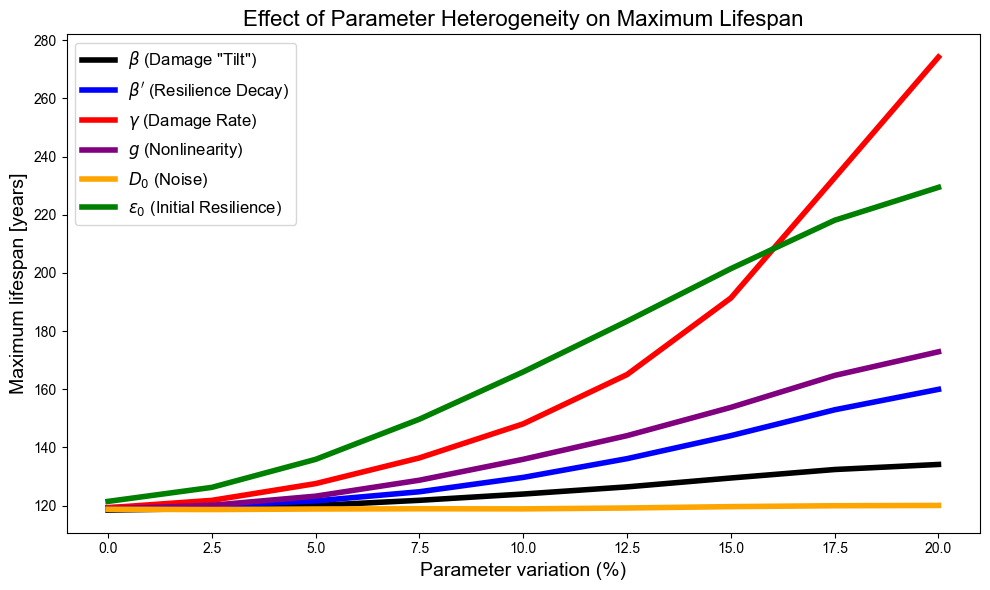

In [73]:
# Load the saved results and plot 10th oldest survivor
import pickle
import os
from scipy.ndimage import gaussian_filter1d

# Load the results
with open('saved_results/fedichev_hetero_results.pkl', 'rb') as f:
    fedichev_hetero_results = pickle.load(f)

params_to_vary = ['beta', 'beta_prime', 'gamma', 'g', 'D0', 'epsilon_0']
std_values = np.arange(0, 0.201, 0.025)

# Define colors matching the fedichev model plot
# Using the same color mapping as in the sensitivity analysis
param_colors = {
    'beta_prime': 'blue',
    'beta': 'black',
    'gamma': 'red',
    'g': 'purple',
    'D0': 'orange',
    'epsilon_0': 'green'
}

# Labels map from the sensitivity analysis
labels_map = {
    'beta_prime': r"$\beta'$ (Resilience Decay)",
    'epsilon_0': r'$\epsilon_0$ (Initial Resilience)',
    'gamma': r'$\gamma$ (Damage Rate)',
    'beta': r'$\beta$ (Damage "Tilt")',
    'g': r'$g$ (Nonlinearity)',
    'D0': r'$D_0$ (Noise)'
}

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

for param in params_to_vary:
    tenth_oldest = []
    for std in std_values:
        top_100 = fedichev_hetero_results[param][f'std_{std:.3f}']
        # Get 10th oldest (10th from the end when sorted)
        sorted_lifespans = np.sort(top_100)
        tenth_oldest.append(sorted_lifespans[-10])
    
    # Smooth the data
    smoothed_data = gaussian_filter1d(tenth_oldest, sigma=1.0)
    
    ax.plot(std_values * 100, smoothed_data, color=param_colors[param], 
            linewidth=4, label=labels_map[param])

ax.set_xlabel('Parameter variation (%)', fontsize=14)
ax.set_ylabel('Maximum lifespan [years]', fontsize=14)
ax.set_title('Effect of Parameter Heterogeneity on Maximum Lifespan', fontsize=16)
ax.legend(fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

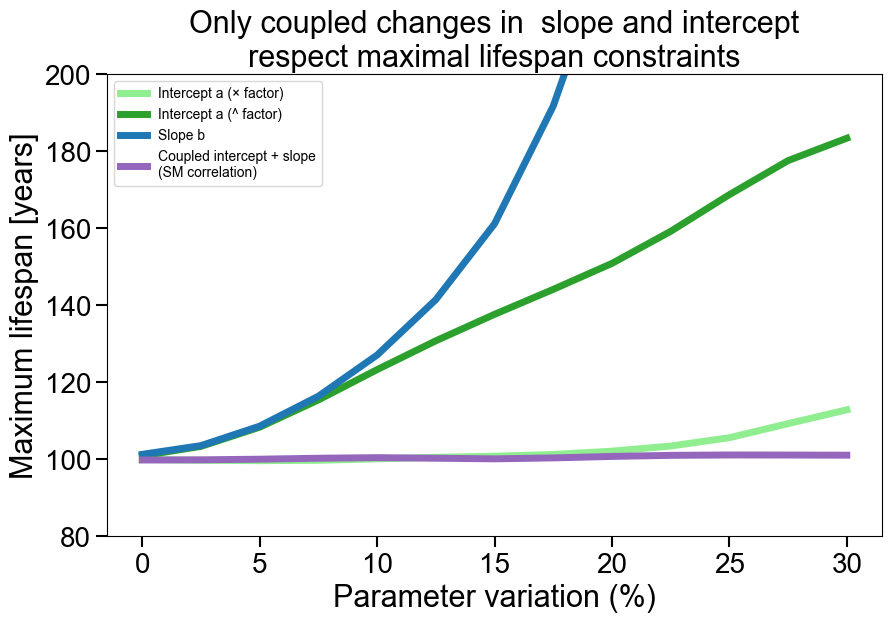

In [57]:
# Define colors and styles matching the build_factor_specs function
param_styles = {
    'a': {'color': '#90EE90', 'label': 'Intercept a (× factor)'},
    'a_power_law': {'color': '#2ca02c', 'label': 'Intercept a (^ factor)'},
    'b': {'color': '#1f77b4', 'label': 'Slope b'},
    'b_coupled': {'color': '#9467bd', 'label': 'Coupled intercept + slope\n(SM correlation)'}
}
fig, ax1 = plt.subplots(figsize=(10, 6))

for param in ['a', 'a_power_law', 'b', 'b_coupled']:
    # Get 10th oldest (10th from the end when sorted) for each std
    tenth_oldest = []
    for top_100 in max_lifespan_results[param]:
        sorted_lifespans = np.sort(top_100)
        tenth_oldest.append(sorted_lifespans[-10])
    
    # Smooth the data
    smoothed_data = gaussian_filter1d(tenth_oldest, sigma=1.0)
    
    ax1.plot(
        np.array(stds)*100, 
        smoothed_data, 
        linewidth=5, 
        color=param_styles[param]['color'],
        label=param_styles[param]['label']
    )

ax1.set_xlabel('Parameter variation (%)', fontsize=22)
ax1.set_ylabel('Maximum lifespan [years]', fontsize=22)
ax1.set_title('Only coupled changes in  slope and intercept\nrespect maximal lifespan constraints', fontsize=22)
ax1.set_ylim(80, 200)
ax1.legend(fontsize=20, prop={'family': 'Arial'})
ax1.grid(False)
ax1.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
